# 🔍 Inspection des paires d'images distantes
Ce notebook analyse les distances entre les paires `img_A` / `img_B` pour vérifier que le filtrage a bien fonctionné.
On cherche à visualiser les paires **les plus distantes** — celles qui auraient dû être filtrées (changement de scène, artefact, etc.).

In [1]:
import os
import sys
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from tqdm.notebook import tqdm
from PIL import Image

# --- CONFIGURATION ---
# DATASET_PATH = "../../data/ytb_gap3_interval5dot0_clean"  # <- Modifie ce chemin si besoin
DATASET_PATH = "../../data/dataset_local"  # <- Modifie ce chemin si besoin
TOP_N        = 20   # Nombre de paires les plus distantes à afficher
THUMB_SIZE   = 16   # Taille de la miniature pour la distance de scène

dir_A = Path(DATASET_PATH) / "img_A"
dir_B = Path(DATASET_PATH) / "img_B"
assert dir_A.exists() and dir_B.exists(), f"Dossiers introuvables dans {DATASET_PATH}"

filenames = sorted([f.name for f in dir_A.iterdir() if f.suffix in ('.jpg', '.png')])
print(f"✅ {len(filenames)} paires trouvées.")

✅ 100 paires trouvées.


## 📐 Définition des métriques de distance

In [2]:
def mse_distance(img1: np.ndarray, img2: np.ndarray) -> float:
    """Mean Squared Error pixel-à-pixel."""
    return float(np.mean((img1.astype(np.float32) - img2.astype(np.float32))**2))


def histogram_distance(img1: np.ndarray, img2: np.ndarray) -> float:
    """Distance de Bhattacharyya sur les histogrammes couleur (0=identique, 1=très différent)."""
    dist = 0.0
    for ch in range(3):
        h1 = cv2.calcHist([img1], [ch], None, [64], [0, 256])
        h2 = cv2.calcHist([img2], [ch], None, [64], [0, 256])
        cv2.normalize(h1, h1)
        cv2.normalize(h2, h2)
        dist += cv2.compareHist(h1, h2, cv2.HISTCMP_BHATTACHARYYA)
    return dist / 3.0


def thumbnail_distance(img1: np.ndarray, img2: np.ndarray, size: int = THUMB_SIZE) -> float:
    """MAE sur une miniature en niveaux de gris (robuste aux petits mouvements)."""
    g1 = cv2.resize(cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY), (size, size))
    g2 = cv2.resize(cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY), (size, size))
    return float(np.mean(np.abs(g1.astype(np.float32) - g2.astype(np.float32))) / 255.0)


print("Métriques définies : MSE | Histogramme (Bhattacharyya) | Miniature (MAE)")

Métriques définies : MSE | Histogramme (Bhattacharyya) | Miniature (MAE)


## 🔄 Calcul des distances sur toutes les paires

In [3]:
records = []  # liste de dicts {filename, mse, hist, thumb}

for fname in tqdm(filenames, desc="Calcul des distances"):
    imgA = cv2.imread(str(dir_A / fname))
    imgB = cv2.imread(str(dir_B / fname))

    if imgA is None or imgB is None:
        continue

    records.append({
        "filename": fname,
        "mse":  mse_distance(imgA, imgB),
        "hist": histogram_distance(imgA, imgB),
        "thumb": thumbnail_distance(imgA, imgB),
    })

print(f"✅ {len(records)} paires analysées.")

Calcul des distances:   0%|          | 0/100 [00:00<?, ?it/s]

✅ 100 paires analysées.


## 📊 Distribution des distances

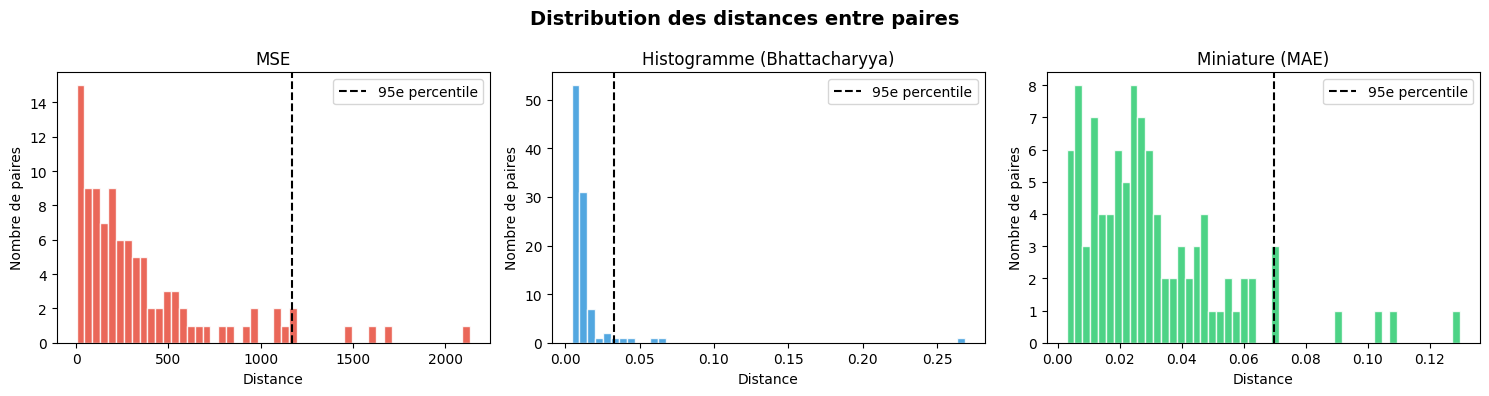


Métrique                            Min    Médiane     95e pc      Max
--------------------------------------------------------------------
MSE                              2.0947   227.1333  1171.8556 2135.3899
Histogramme                      0.0043     0.0092     0.0330   0.2690
Miniature                        0.0029     0.0252     0.0698   0.1299


In [4]:
mse_vals   = np.array([r["mse"]   for r in records])
hist_vals  = np.array([r["hist"]  for r in records])
thumb_vals = np.array([r["thumb"] for r in records])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Distribution des distances entre paires", fontsize=14, fontweight="bold")

for ax, vals, label, color in zip(
    axes,
    [mse_vals, hist_vals, thumb_vals],
    ["MSE", "Histogramme (Bhattacharyya)", "Miniature (MAE)"],
    ["#e74c3c", "#3498db", "#2ecc71"]
):
    ax.hist(vals, bins=50, color=color, alpha=0.85, edgecolor="white")
    ax.axvline(np.percentile(vals, 95), color="black", linestyle="--", label="95e percentile")
    ax.set_title(label)
    ax.set_xlabel("Distance")
    ax.set_ylabel("Nombre de paires")
    ax.legend()

plt.tight_layout()
plt.show()

print(f"\n{'Métrique':<30} {'Min':>8} {'Médiane':>10} {'95e pc':>10} {'Max':>8}")
print("-" * 68)
for label, vals in [("MSE", mse_vals), ("Histogramme", hist_vals), ("Miniature", thumb_vals)]:
    print(f"{label:<30} {vals.min():>8.4f} {np.median(vals):>10.4f} {np.percentile(vals,95):>10.4f} {vals.max():>8.4f}")

## 🚨 Top N paires les plus distantes
Ces paires sont les **candidates aux faux positifs** — potentiellement deux scènes différentes.

In [5]:
# Trier par distance histogramme (la plus fiable pour les changements de scène)
sorted_records = sorted(records, key=lambda r: r["hist"], reverse=True)
top_records    = sorted_records[:TOP_N]

print(f"Top {TOP_N} paires les plus distantes (triées par distance histogramme) :")
print(f"\n{'#':<4} {'Fichier':<25} {'MSE':>10} {'Hist':>8} {'Thumb':>8}")
print("-" * 60)
for i, r in enumerate(top_records):
    print(f"{i+1:<4} {r['filename']:<25} {r['mse']:>10.1f} {r['hist']:>8.4f} {r['thumb']:>8.4f}")

Top 20 paires les plus distantes (triées par distance histogramme) :

#    Fichier                          MSE     Hist    Thumb
------------------------------------------------------------
1    pair_000067.jpg               2135.4   0.2690   0.1299
2    pair_000082.jpg                317.9   0.0640   0.0278
3    pair_000042.jpg                102.5   0.0583   0.0173
4    pair_000040.jpg                292.3   0.0464   0.0390
5    pair_000041.jpg                 83.2   0.0386   0.0221
6    pair_000081.jpg               1597.0   0.0328   0.1034
7    pair_000096.jpg                261.5   0.0262   0.0324
8    pair_000077.jpg                245.7   0.0261   0.0231
9    pair_000058.jpg                379.3   0.0238   0.0470
10   pair_000000.jpg                 20.6   0.0195   0.0071
11   pair_000083.jpg                197.5   0.0182   0.0153
12   pair_000014.jpg                 62.2   0.0181   0.0130
13   pair_000062.jpg                188.0   0.0177   0.0286
14   pair_000003.jpg         

## 🖼️ Visualisation des paires suspectes

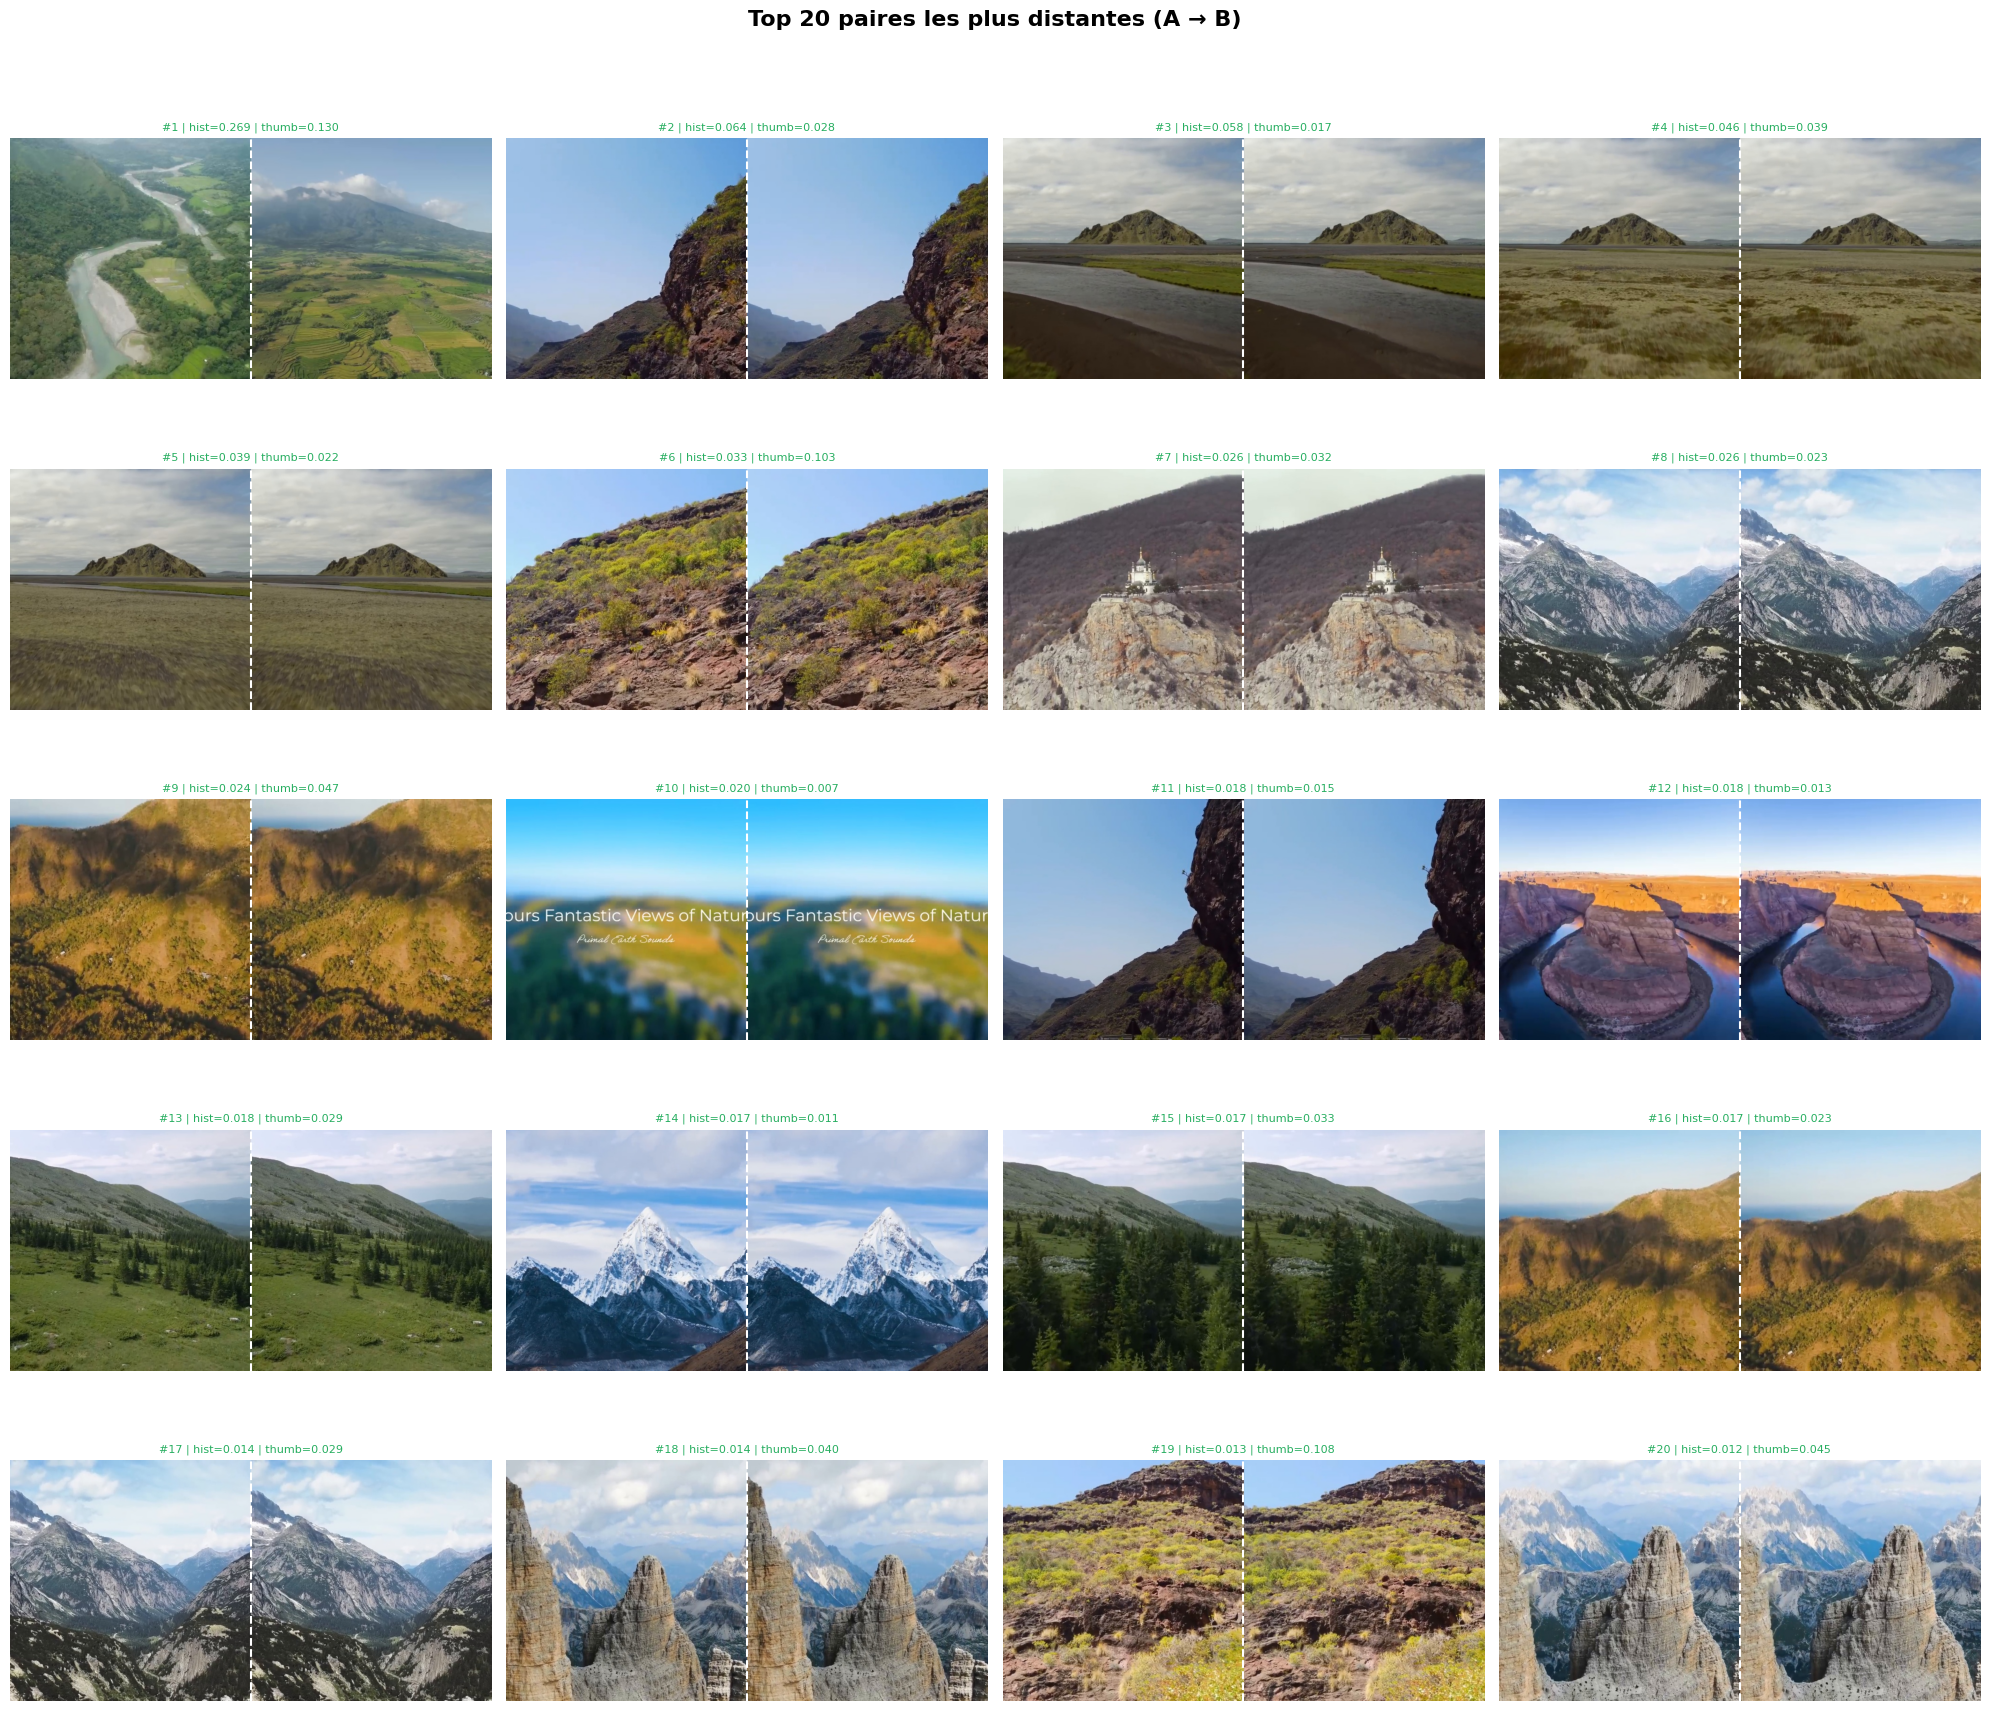

🔴 Titre rouge = distance histogramme > 0.35 (potentiel changement de scène)
🟢 Titre vert  = distance histogramme ≤ 0.35 (paire probablement valide)


In [6]:
COLS = 4  # Nombre de paires par ligne
ROWS = (TOP_N + COLS - 1) // COLS

fig = plt.figure(figsize=(COLS * 5, ROWS * 3.5))
fig.suptitle(f"Top {TOP_N} paires les plus distantes (A → B)", fontsize=16, fontweight="bold", y=1.01)

for i, r in enumerate(top_records):
    imgA = cv2.cvtColor(cv2.imread(str(dir_A / r["filename"])), cv2.COLOR_BGR2RGB)
    imgB = cv2.cvtColor(cv2.imread(str(dir_B / r["filename"])), cv2.COLOR_BGR2RGB)

    # Concaténer A et B côte à côte
    pair_img = np.concatenate([imgA, imgB], axis=1)

    ax = fig.add_subplot(ROWS, COLS, i + 1)
    ax.imshow(pair_img)
    ax.axis("off")
    ax.set_title(
        f"#{i+1} | hist={r['hist']:.3f} | thumb={r['thumb']:.3f}",
        fontsize=8,
        color="#c0392b" if r["hist"] > 0.35 else "#27ae60"
    )
    # Ligne de séparation A|B
    ax.axvline(imgA.shape[1], color="white", linewidth=1.5, linestyle="--")

plt.tight_layout()
plt.show()
print("🔴 Titre rouge = distance histogramme > 0.35 (potentiel changement de scène)")
print("🟢 Titre vert  = distance histogramme ≤ 0.35 (paire probablement valide)")

## 🔬 Inspection manuelle d'une paire spécifique

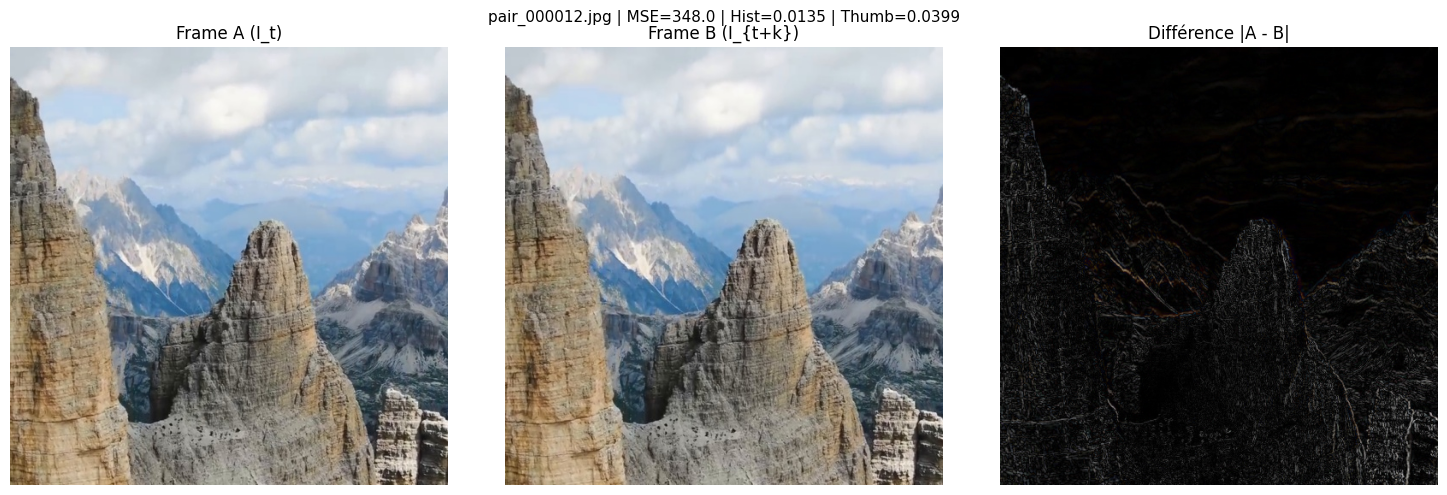

In [21]:
# Change ce nom pour inspecter une paire précise
import random
INSPECT_FILE = top_records[random.randint(0, len(top_records) - 1)]["filename"]

imgA = cv2.cvtColor(cv2.imread(str(dir_A / INSPECT_FILE)), cv2.COLOR_BGR2RGB)
imgB = cv2.cvtColor(cv2.imread(str(dir_B / INSPECT_FILE)), cv2.COLOR_BGR2RGB)
diff = np.abs(imgA.astype(np.float32) - imgB.astype(np.float32)).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img, title in zip(axes, [imgA, imgB, diff], ["Frame A (I_t)", "Frame B (I_{t+k})", "Différence |A - B|"]):
    ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

r = next(rec for rec in records if rec["filename"] == INSPECT_FILE)
fig.suptitle(f"{INSPECT_FILE} | MSE={r['mse']:.1f} | Hist={r['hist']:.4f} | Thumb={r['thumb']:.4f}", fontsize=11)
plt.tight_layout()
plt.show()